### Libraries and Imports

In [9]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../src")

from polymer import Polymer
from md import verlet_step
from forces import forcesOnPolymer
from observables import bond_lengths, bond_vectors

polymer = Polymer(
    nMonomers=25,
    bondLength=0.5,
    m=4,
    k=100,
    box=[10,10,10],
    kBT=1,
    seed=19,
    dt = 0.0001
)


### Genaration of a Polymer (__Linear__)

Rel. distnces between monomers:[np.float64(0.9652616577754866), np.float64(1.0302609985912183), np.float64(1.0044939274199283), np.float64(1.0379651957482656), np.float64(0.9713993862951118), np.float64(0.9785467731987092), np.float64(0.9514347437186733), np.float64(0.9768937811139886), np.float64(0.9637758455675768), np.float64(1.0252482018176408), np.float64(1.0174443295496527), np.float64(0.9586329432707389), np.float64(1.044582253437645), np.float64(0.995684339888307), np.float64(1.0470435438140275), np.float64(0.9731711863661366), np.float64(1.0490110243329571), np.float64(1.015873433299714), np.float64(1.042818565462424), np.float64(1.024171462323233), np.float64(1.0290275679984968), np.float64(0.9609709327340986), np.float64(1.0156582809168664), np.float64(0.9704646910615099)]


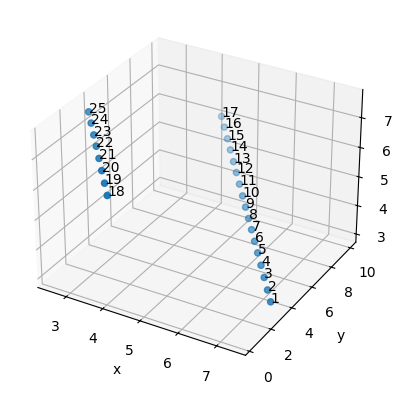

In [10]:
polymer.generateLinearPositions()

#print(f"Positions of monomers:{polymer.r}\n")
print(f"Rel. distnces between monomers:{[polymer.distInBC(i, i+1)/polymer.bondLength for i in range(0, polymer.nMonomers-1)]}") 

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    polymer.r[:, 0],
    polymer.r[:, 1],
    polymer.r[:, 2]
)
for i in range(len(polymer.r)):
    ax.text(polymer.r[i, 0], polymer.r[i, 1], polymer.r[i, 2], str(i+1))

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

Rel. distnces between monomers:[np.float64(1.0109086030132), np.float64(0.9962312562717038), np.float64(0.9677827833667542), np.float64(0.9872033524613092), np.float64(1.0005385998563212), np.float64(0.9892458186819226), np.float64(0.9621949980748395), np.float64(0.9978846257933502), np.float64(0.9864536698820727), np.float64(1.0198828432981824), np.float64(1.0357046336551978), np.float64(1.0360476401434415), np.float64(1.0250101780301268), np.float64(1.0331964434297383), np.float64(1.0092697750700765), np.float64(1.0052148041904299), np.float64(0.9560399375078357), np.float64(0.9959443826264269), np.float64(0.9787662399451282), np.float64(1.0009010219117838), np.float64(0.9583282298516623), np.float64(0.9972510313982804), np.float64(1.0011981559964236), np.float64(1.0142926703137474)]


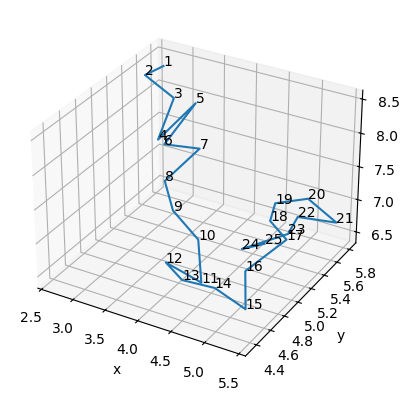

In [11]:
polymer.generateRandomWalk()

#print(f"Positions of monomers:{polymer.r}\n")
print(f"Rel. distnces between monomers:{[polymer.distInBC(i, i+1)/polymer.bondLength for i in range(0, polymer.nMonomers-1)]}") 

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    polymer.r[:, 0],
    polymer.r[:, 1],
    polymer.r[:, 2]
)
for i in range(len(polymer.r)):
    ax.text(polymer.r[i, 0], polymer.r[i, 1], polymer.r[i, 2], str(i+1))

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

In [12]:
def average_length():
    return bond_lengths(polymer).mean()


In [13]:
polymer_frames = []
frame_steps = []


save_every = 5

polymer_frames.append(polymer.r.copy())
frame_steps.append(0)

def polymer_length():
    return polymer.distInBC(0, -1)

average = [average_length()]
absolute_length = [polymer_length()]
for step in range(150000):
    verlet_step(polymer, 0.0001, forcesOnPolymer)
    average.append(average_length())
    absolute_length.append(polymer_length())
    if step % save_every == 0:
        polymer_frames.append(polymer.r.copy())
        frame_steps.append(step)

polymer_frames = np.array(polymer_frames)   # shape: (n_frames, n_monomers, 3)
frame_steps = np.array(frame_steps)

average = np.array(average)


    


Shortest average: 0.48626695403270315/nLongest average0.5636978548319911/nDifference: 0.07743090079928794


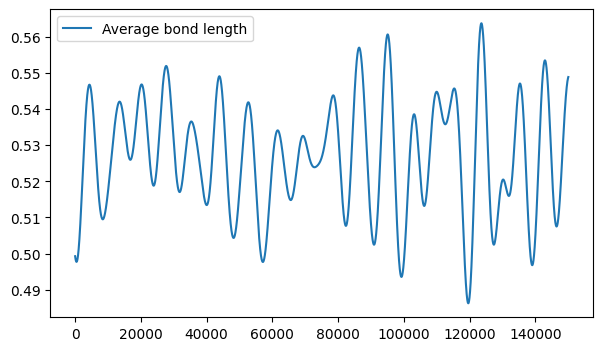

In [14]:
print(f"Shortest average: {average.min()}/nLongest average{average.max()}/nDifference: {average.max() - average.min()}")

plt.figure(figsize=(7, 4))
plt.plot(average, label="Average bond length")
plt.legend()
plt.show()


## Absolute polymer length

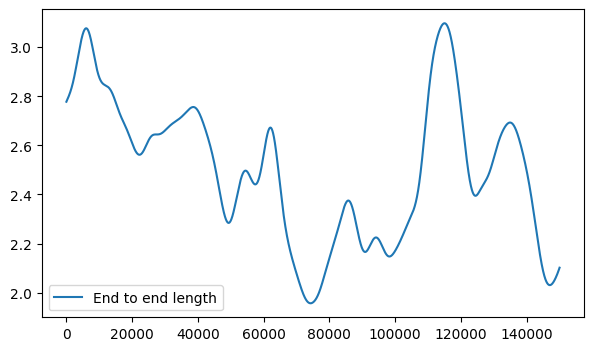

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(absolute_length, label="End to end length")
plt.legend()
plt.show()

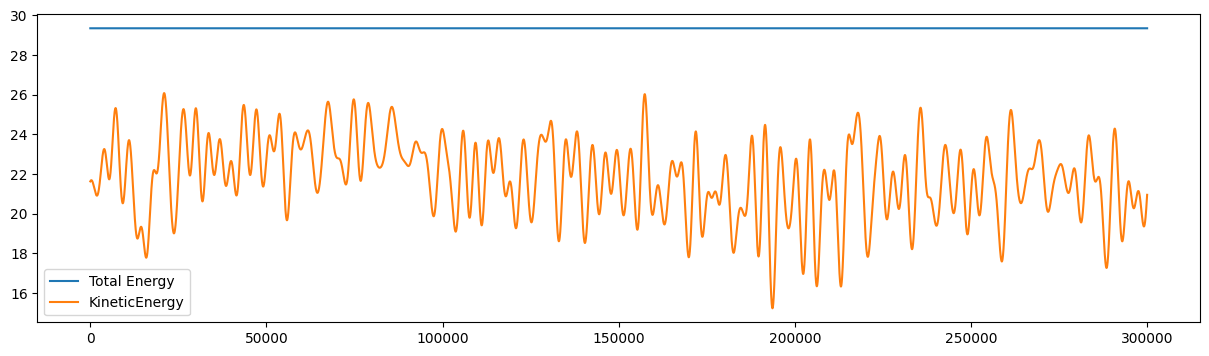

In [16]:
energy = [polymer.totalEnergy()]
k_energy = [polymer.kineticEnergy()]
b = [bond_vectors(polymer)]
for step in range(300000):
    verlet_step(polymer, 0.0001, forcesOnPolymer)
    energy.append(polymer.totalEnergy())
    k_energy.append(polymer.kineticEnergy())
    if step % 10 == 0:
        b.append(bond_vectors(polymer))
        

b = np.array(b)

energy = np.array(energy)

plt.figure(figsize=(15, 4))
plt.plot(energy, label='Total Energy')
plt.plot(k_energy, label='KineticEnergy')
plt.legend()
plt.show()


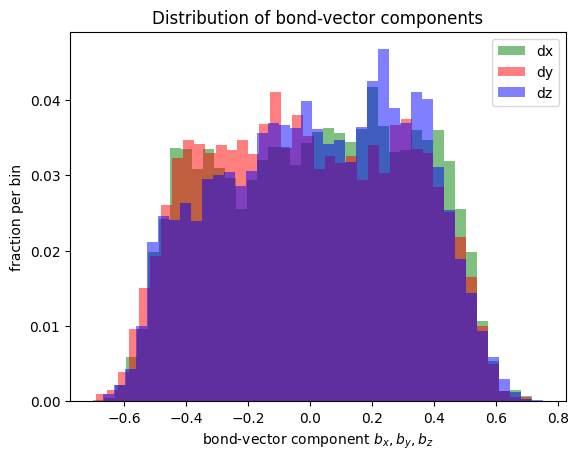

In [17]:
bond_length_history = np.linalg.norm(b, axis=2)
lengths_all = bond_length_history.ravel()
weights = np.ones_like(lengths_all) / len(lengths_all)

plt.figure()
plt.hist(b[:, :, 0].ravel(), bins=40, weights=weights, alpha=0.5, label="dx", color="green")
plt.hist(b[:, :, 1].ravel(), bins=40, weights=weights, alpha=0.5, label="dy", color="red")
plt.hist(b[:, :, 2].ravel(), bins=40, weights=weights, alpha=0.5, label="dz", color="blue")
plt.xlabel(r"bond-vector component $b_x, b_y, b_z$")
plt.ylabel("fraction per bin")
plt.title("Distribution of bond-vector components")
plt.legend()
plt.show()

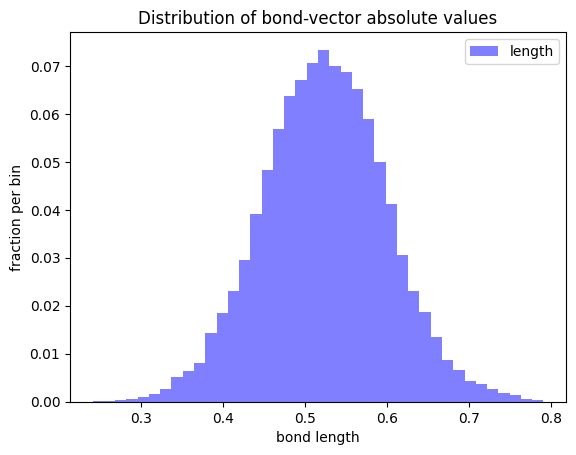

In [18]:
plt.figure()
plt.hist(lengths_all, bins=40, weights=weights, alpha=0.5, label="length", color="blue")
plt.title("Distribution of bond-vector absolute values")
plt.xlabel("bond length")
plt.ylabel("fraction per bin")
plt.legend()
plt.show()